<a href="https://colab.research.google.com/github/ChDamodhar/Machine-Learning/blob/main/DecisionTrees2%26Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [156]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([50,120,180,250,320,380]).reshape(-1,1)
y = np.array([500,1000,1500,1800,2500,2500]).reshape(-1,1)

In [157]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(max_depth=4,random_state=42)
dt_reg.fit(X,y)

DecisionTreeRegressor(max_depth=4, random_state=42)

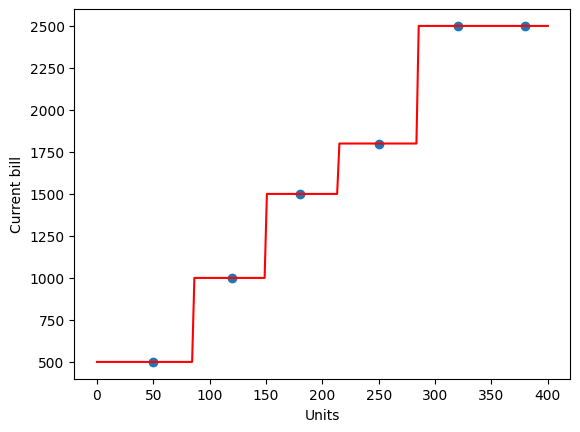

In [158]:
X_grid = np.linspace(0,400,200).reshape(-1,1)
y_pred = dt_reg.predict(X_grid)

plt.scatter(X,y)
plt.plot(X_grid,y_pred,color='red')
plt.xlabel('Units')
plt.ylabel('Current bill')
plt.show()

In [159]:
units = float(input("Enter the units of electricity consumed: "))
bill = dt_reg.predict([[units]])

bill_amount = bill[0]
print(f"The bill is: {bill_amount:.2f}")


Enter the units of electricity consumed: 56
The bill is: 500.00


# **Experience and salary**

In [160]:
X = np.array([1,2,3,4,5,7,8,9]).reshape(-1,1)
y = np.array([3,3.5,4,4.2,6,6.5,7,7.2])

In [161]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

In [162]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(max_depth=4,random_state=42)
dt_reg.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

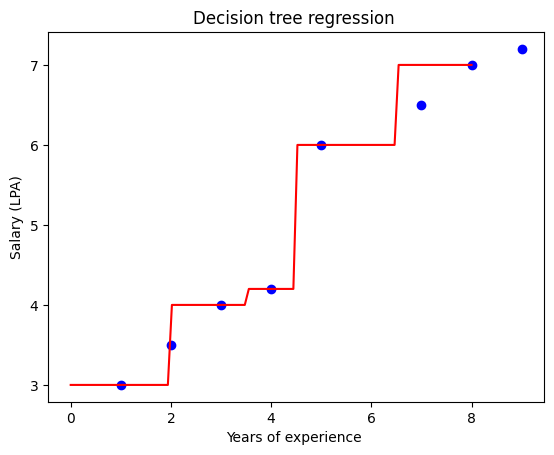

In [163]:
X_grid = np.linspace(0,8,100).reshape(-1,1)
y_pred = dt_reg.predict(X_grid)

plt.scatter(X,y,color='blue')
plt.plot(X_grid,y_pred,color='red')
plt.title('Decision tree regression ')
plt.xlabel('Years of experience ')
plt.ylabel('Salary (LPA)')
plt.show()

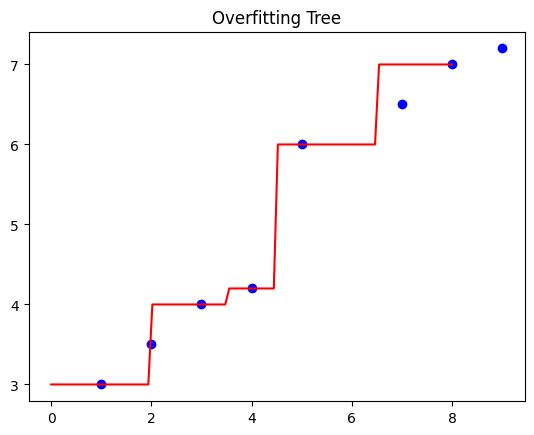

In [164]:
dt_deep = DecisionTreeRegressor(max_depth=None)
dt_deep.fit(X_train,y_train)

y_pred_deep = dt_deep.predict(X_grid)

plt.scatter(X,y,color='blue')
plt.plot(X_grid,y_pred_deep,color='red')
plt.title("Overfitting Tree")
plt.show()

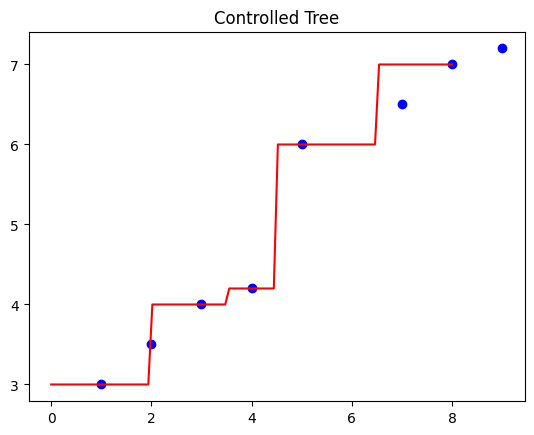

In [165]:
dt_controlled = DecisionTreeRegressor(max_depth=3)
dt_controlled.fit(X_train,y_train)

y_pred_controlled = dt_controlled.predict(X_grid)

plt.scatter(X,y,color='blue')
plt.plot(X_grid,y_pred_controlled,color='red')
plt.title("Controlled Tree")
plt.show()


In [166]:
#Metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

y_test_pred_deep = dt_deep.predict(X_test)
y_test_pred_controlled = dt_controlled.predict(X_test)

print("Deep Tree Metrics")
print("MSE: ",mean_squared_error(y_test,y_test_pred_deep))
print("R2: ",r2_score(y_test,y_test_pred_deep))

print("Controlled Tree Metrics")
print("MSE: ",mean_squared_error(y_test,y_test_pred_controlled))
print("R2: ",r2_score(y_test,y_test_pred_controlled))



Deep Tree Metrics
MSE:  0.25
R2:  0.8888888888888888
Controlled Tree Metrics
MSE:  0.25
R2:  0.8888888888888888


In [167]:
np.random.seed(42)

X = np.arange(1,21).reshape(-1,1)
y=np.array([
    10,12,15,18,20,25,30,28,35,40,
    45,42,50,55,60,58,65,70,72,75
])

In [168]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
    )

In [169]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(max_depth=4,random_state=42)
dt_reg.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

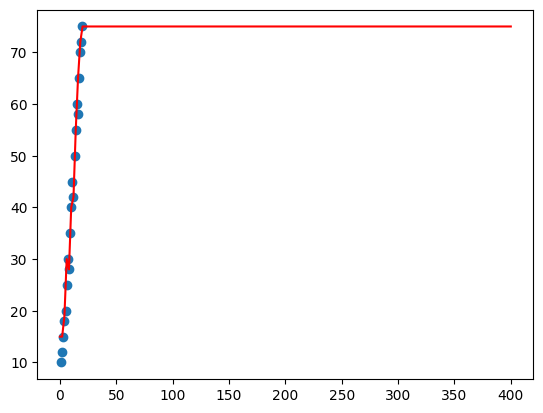

In [170]:
X_grid = np.linspace(0,400,200).reshape(-1,1)
y_pred = dt_reg.predict(X_grid)

plt.scatter(X,y)
plt.plot(X_grid,y_pred,color='red')
plt.show()

In [171]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
y_test_pred = dt_reg.predict(X_test)

print("MSE: ",mean_squared_error(y_test,y_test_pred))
print("R2: ",r2_score(y_test,y_test_pred))
#

MSE:  24.666666666666668
R2:  0.9507978723404256


In [172]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100,random_state=42)
rf_reg.fit(X_train,y_train)
y_pred = rf_reg.predict(X_test)


In [173]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
y_test_pred = rf_reg.predict(X_test)
print("Random forest Metrics")
print("MSE: ",mean_squared_error(y_test,y_test_pred))
print("R2: ",r2_score(y_test,y_test_pred))

print("Decision tree Metrics")
print("MSE: ",mean_squared_error(y_test,y_test_pred_deep))
print("R2: ",r2_score(y_test,y_test_pred_deep))


Random forest Metrics
MSE:  17.557066666666667
R2:  0.964979255319149
Decision tree Metrics


ValueError: Found input variables with inconsistent numbers of samples: [6, 2]

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [175]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/house_data.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [176]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [178]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [179]:
# Date feature engineering
df['date'] = pd.to_datetime(df['date'])
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df.drop('date', axis=1, inplace=True)

# Drop high-cardinality column
df.drop('street', axis=1, inplace=True)

In [180]:
X = df.drop('price', axis=1)
y = df['price']

X = pd.get_dummies(
    X,
    columns=['city', 'statezip', 'country'],
    drop_first=True
)


In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [182]:
dt_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=3, random_state=42)

In [183]:
dt_pred = dt_model.predict(X_test)


In [184]:
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MSE:", dt_mse)
print("Decision Tree R²:", dt_r2)


Decision Tree MSE: 1001207930299.1442
Decision Tree R²: 0.018275703951853517


In [185]:
rf_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=3, n_estimators=10, random_state=42)

In [186]:
rf_pred = rf_model.predict(X_test)


In [187]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R²:", rf_r2)


Random Forest MSE: 985788320779.1902
Random Forest R²: 0.03339524590033882


In [188]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'MSE': [dt_mse, rf_mse],
    'R² Score': [dt_r2, rf_r2]
})

comparison


,Model,MSE,R² Score
0,Decision Tree,1.001208e+12,0.018276
1,Random Forest,9.857883e+11,0.033395


In [189]:
new_house = pd.DataFrame([{
    'bedrooms': 4,
    'bathrooms': 3,
    'sqft_living': 2800,
    'sqft_lot': 5000,
    'floors': 2,
    'waterfront': 0,
    'view': 2,
    'condition': 4,
    'sqft_above': 1800,
    'sqft_basement': 1000,
    'yr_built': 2015,
    'yr_renovated': 0,
    'year_sold': 2024,
    'month_sold': 6,
    'city': 'Seattle',
    'statezip': 'WA 98103',
    'country': 'USA'
}])

new_house = pd.get_dummies(new_house)
new_house = new_house.reindex(columns=X.columns, fill_value=0)

dt_price = dt_model.predict(new_house)[0]
rf_price = rf_model.predict(new_house)[0]

print(f"Decision Tree Prediction: {dt_price:.2f}")
print(f"Random Forest Prediction: {rf_price:.2f}")


Decision Tree Prediction: 547309.17
Random Forest Prediction: 555181.18


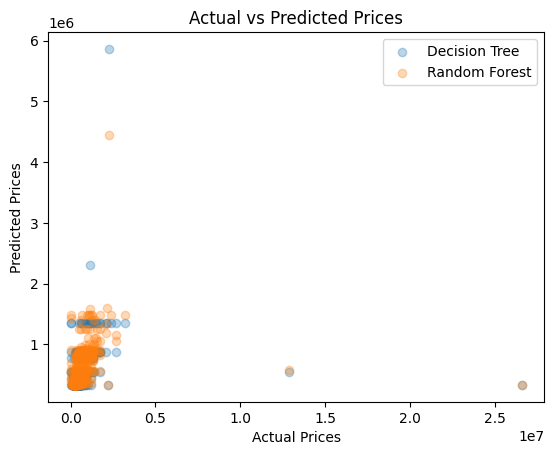

In [190]:
plt.figure()
plt.scatter(y_test, dt_pred, alpha=0.3, label="Decision Tree")
plt.scatter(y_test, rf_pred, alpha=0.3, label="Random Forest")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [192]:
X = np.array([1,2,3,4,5,6]).reshape(-1,1)
y = np.array([35,40,50,60,65,70])

In [193]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [194]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)


LinearRegression()

In [195]:
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

In [196]:
print("Good fit Linear Regression")
print('Training set MSE:', mean_squared_error(y_train, y_train_pred))
print("Train R2:",r2_score(y_train,y_train_pred))
print('Test set MSE:', mean_squared_error(y_test, y_test_pred))
print("Test R2:",r2_score(y_test,y_test_pred))
#

Good fit Linear Regression
Training set MSE: 1.875
Train R2: 0.9657142857142857
Test set MSE: 18.625
Test R2: -1.98


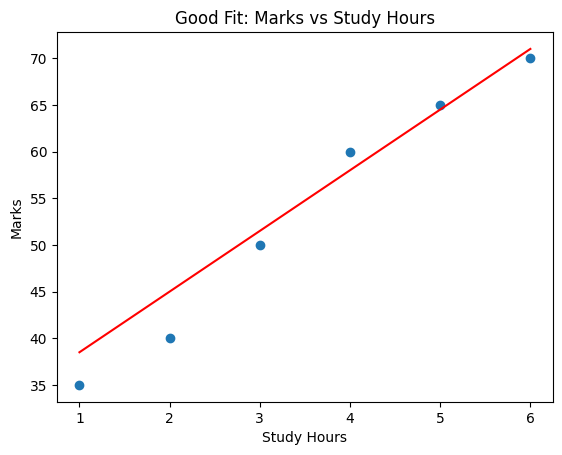

In [197]:

plt.scatter(X, y)
plt.plot(X, lr_model.predict(X), color='red')
plt.title("Good Fit: Marks vs Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()

In [198]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=5)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

overfit_model = LinearRegression()
overfit_model.fit(X_train_poly, y_train)

y_train_pred_poly = overfit_model.predict(X_train_poly)
y_test_pred_poly = overfit_model.predict(X_test_poly)

In [199]:
print("Overfitting Linear Regression")
print('Training set MSE:', mean_squared_error(y_train, y_train_pred_poly))
print("Train R2:",r2_score(y_train,y_train_pred_poly))

Overfitting Linear Regression
Training set MSE: 8.363894592162157e-24
Train R2: 1.0


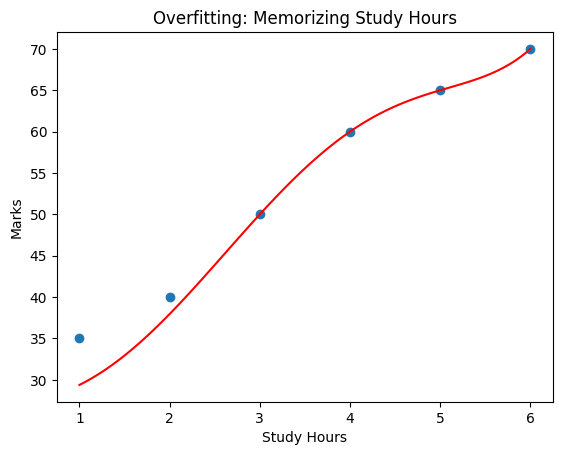

In [200]:
X_grid = np.linspace(1, 6, 100).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

plt.scatter(X, y)
plt.plot(X_grid, overfit_model.predict(X_grid_poly), color='red')
plt.title("Overfitting: Memorizing Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()


In [201]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X)


In [202]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_poly, y)

y_ridge_pred = ridge.predict(X_poly)


In [203]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_poly, y)

y_ridge_pred = ridge.predict(X_poly)


In [204]:
from sklearn.metrics import mean_squared_error, r2_score

print("Ridge MSE:", mean_squared_error(y, y_ridge_pred))
print("Ridge R² :", r2_score(y, y_ridge_pred))



Ridge MSE: 0.24058058055628095
Ridge R² : 0.9985320506949108


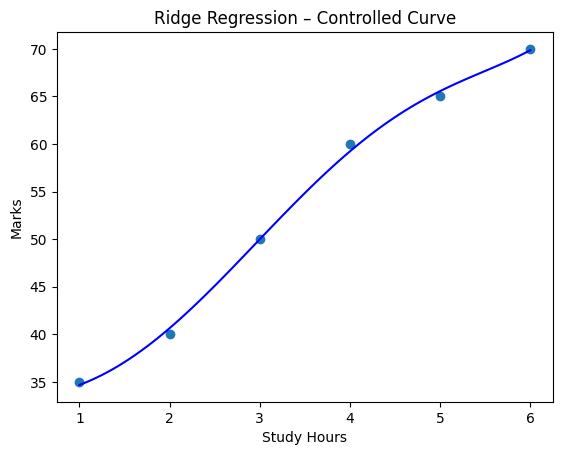

In [205]:
import matplotlib.pyplot as plt

X_grid = np.linspace(1, 6, 100).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

plt.scatter(X, y)
plt.plot(X_grid, ridge.predict(X_grid_poly), color='blue')
plt.title("Ridge Regression – Controlled Curve")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()


In [206]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_poly, y)

y_lasso_pred = lasso.predict(X_poly)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.580e+00, tolerance: 9.833e-02
  model = cd_fast.enet_coordinate_descent(


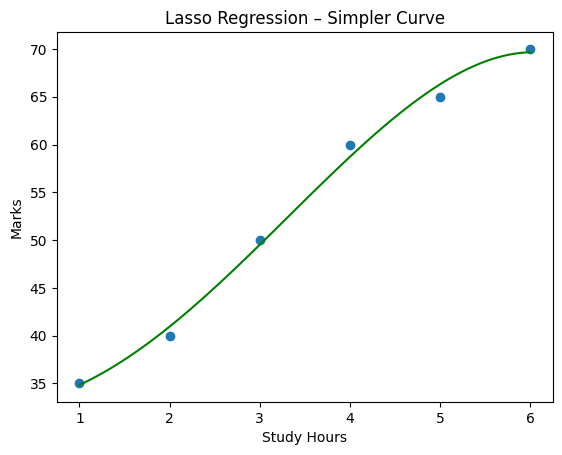

In [207]:
plt.scatter(X, y)
plt.plot(X_grid, lasso.predict(X_grid_poly), color='green')
plt.title("Lasso Regression – Simpler Curve")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()


In [208]:
from sklearn.metrics import mean_squared_error, r2_score

print("Ridge MSE:", mean_squared_error(y, y_ridge_pred))
print("Ridge R² :", r2_score(y, y_ridge_pred))

print("\nLasso MSE:", mean_squared_error(y, y_lasso_pred))
print("Lasso R² :", r2_score(y, y_lasso_pred))


Ridge MSE: 0.24058058055628095
Ridge R² : 0.9985320506949108

Lasso MSE: 0.7727384155729786
Lasso R² : 0.9952849859388767


In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [210]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define file path
file_path = '/content/drive/MyDrive/spam.csv'

# Read CSV with correct encoding
df = pd.read_csv(file_path, encoding='latin-1')[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'text']

# Convert labels to numeric
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Display data
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


# **Gaussian Naive Bayes (For continuous)**

In [211]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df['text_length'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(x.split()))
df['num_digits'] = df['text'].apply(lambda x: sum(c.isdigit() for c in x))

# Define features and target
X = df [['text_length', 'num_words', 'num_digits']]
y = df['label']
#Split dataset
X_train, X_test, y_train, y_test= train_test_split(X, y,test_size=0.2,random_state=42)

# Standardize features
scaler = StandardScaler()
scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)
#
#Train Gaussian Naïve Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_gnb)
print(f'Accuracy: {accuracy}')



Accuracy: 0.9802690582959641


In [212]:
cm = confusion_matrix(y_test, y_pred_gnb)
print(cm)

[[953  12]
 [ 10 140]]


# **Multinomial Naive Bayes (For text data)**

In [213]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

model = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('nb', MultinomialNB())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9668161434977578
Confusion Matrix:
 [[965   0]
 [ 37 113]]


# **Bernouli Naive Bayes**(For Binary Features)

In [214]:
from sklearn.naive_bayes import BernoulliNB
# Convert text into binary presence/absence of important words
important_words = ["free", "win", "offer", "money", "urgent"]
for word in important_words:
  df[word] = df['text'].apply(lambda x: 1 if word in x.lower() else 0)

# Define features and target
X = df[important_words]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Bernoulli Naïve Bayes
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_bnb)
print(f'Accuracy: {accuracy}')

cm= confusion_matrix(y_test, y_pred_bnb)
print(cm)

Accuracy: 0.895067264573991
[[929  36]
 [ 81  69]]


ValueError: Found input variables with inconsistent numbers of samples: [1115, 5]

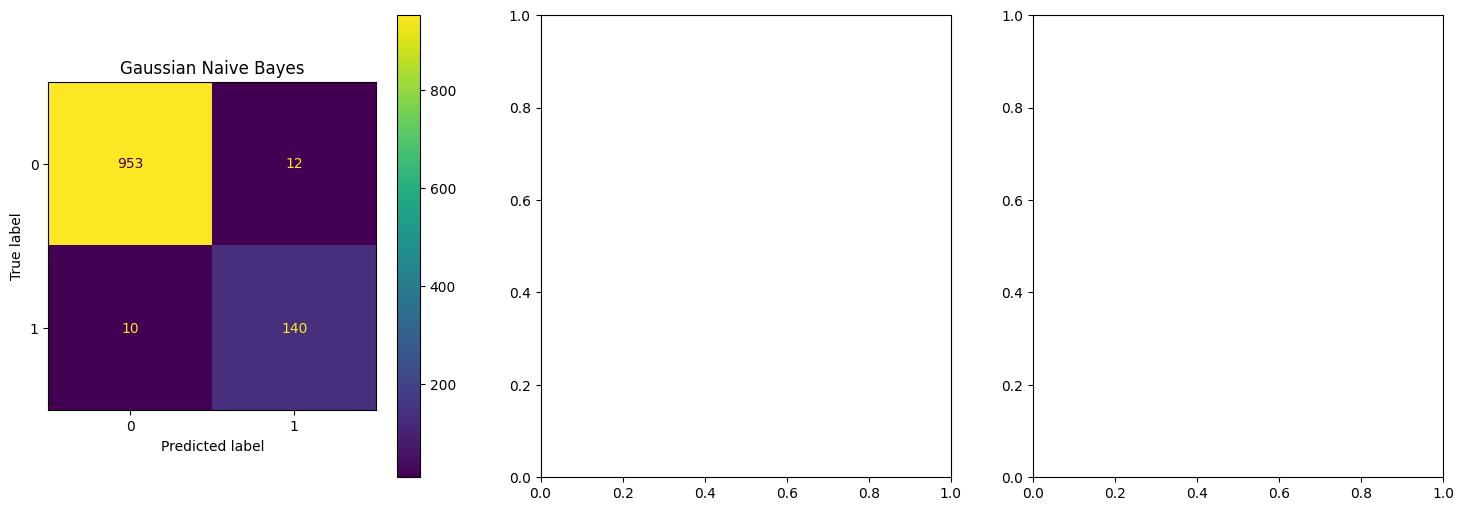

In [215]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ------------------ Gaussian Naive Bayes ------------------
ConfusionMatrixDisplay.from_estimator(
    gnb,
    X_test_scaled,
    y_test,
    ax=axes[0]
)
axes[0].set_title("Gaussian Naive Bayes")

# ------------------ Multinomial Naive Bayes ------------------
ConfusionMatrixDisplay.from_estimator(
    model,          # Pipeline handles vectorization
    X_test,         # text input is correct here
    y_test,
    ax=axes[1]
)
axes[1].set_title("Multinomial Naive Bayes")

# ------------------ Bernoulli Naive Bayes ------------------
ConfusionMatrixDisplay.from_estimator(
    bnb,
    X_test_bnb,     # ✅ binary features ONLY
    y_test_bnb,
    ax=axes[2]
)
axes[2].set_title("Bernoulli Naive Bayes")

plt.tight_layout()
plt.show()


In [216]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

# Load dataset (SMS Spam Collection)
file_path = '/content/drive/MyDrive/spam.csv'
df = pd.read_csv(file_path, encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [217]:
category_counts = df['label'].value_counts()
print(category_counts)


label
ham     4825
spam     747
Name: count, dtype: int64


In [218]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

# Convert labels
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label_num'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_num']
)

model = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('nb', MultinomialNB())
])

model.fit(X_train, y_train)


Pipeline(steps=[('vectorizer', CountVectorizer(stop_words='english')),
                ('tfidf', TfidfTransformer()), ('nb', MultinomialNB())])

In [219]:
y_pred = model.predict(X_test)


In [220]:
def predict_message(msg):
    pred = model.predict([msg])[0]
    return "Suspicious" if pred == 1 else "Not Suspicious"

# Example tests
print(predict_message("Congratulations! You have won a free lottery ticket"))
print(predict_message("Are we meeting tomorrow at 10 AM?"))


Not Suspicious
Not Suspicious


In [221]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Not Suspicious", "Suspicious"]))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Accuracy: 0.968609865470852

Classification Report:

                precision    recall  f1-score   support

Not Suspicious       0.97      1.00      0.98       966
    Suspicious       1.00      0.77      0.87       149

      accuracy                           0.97      1115
     macro avg       0.98      0.88      0.92      1115
  weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
 [[966   0]
 [ 35 114]]
